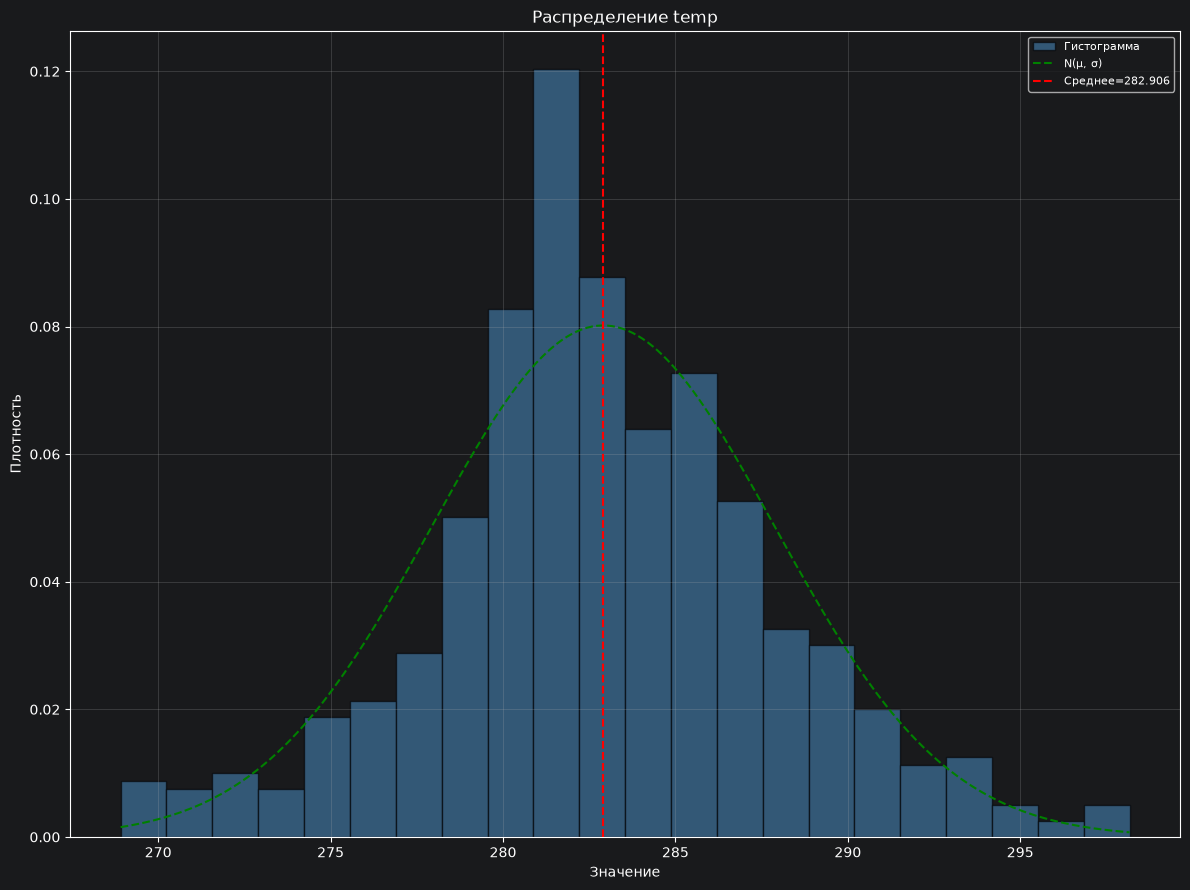

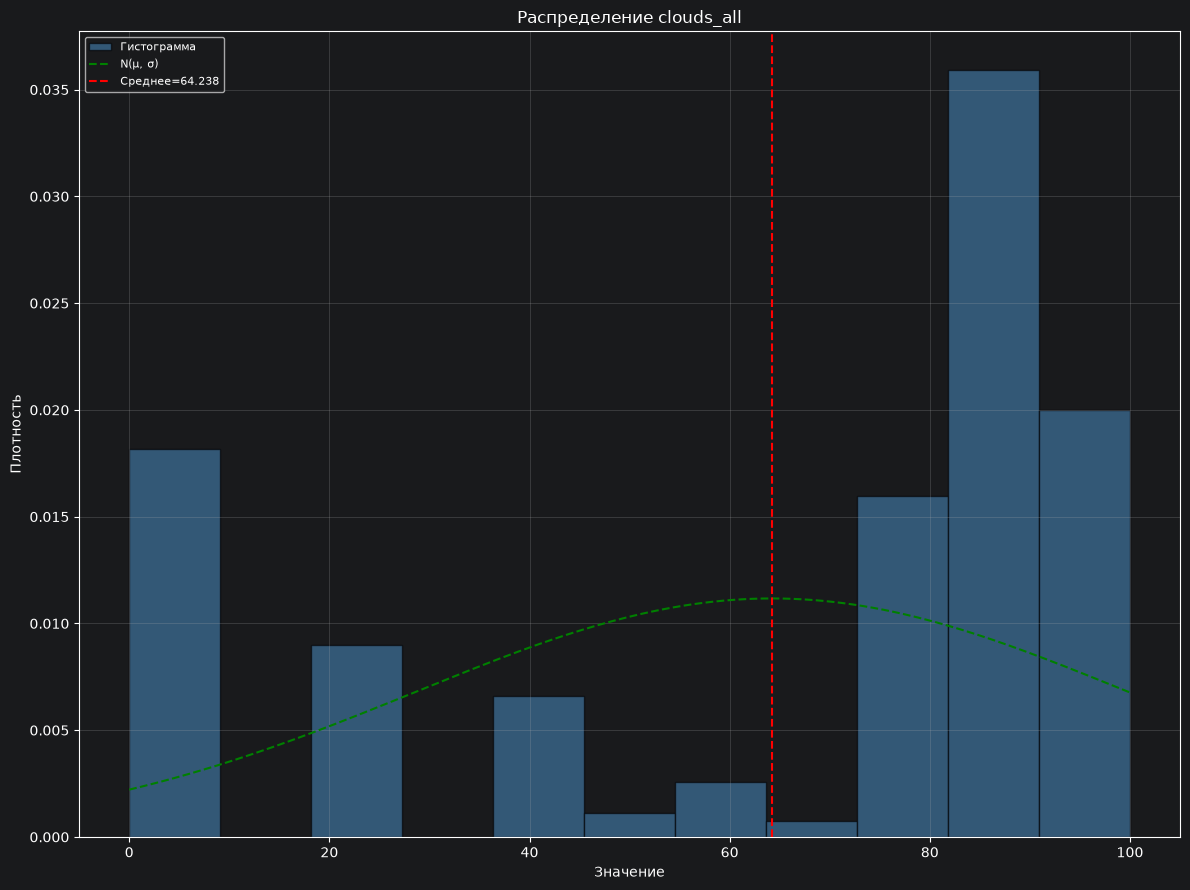

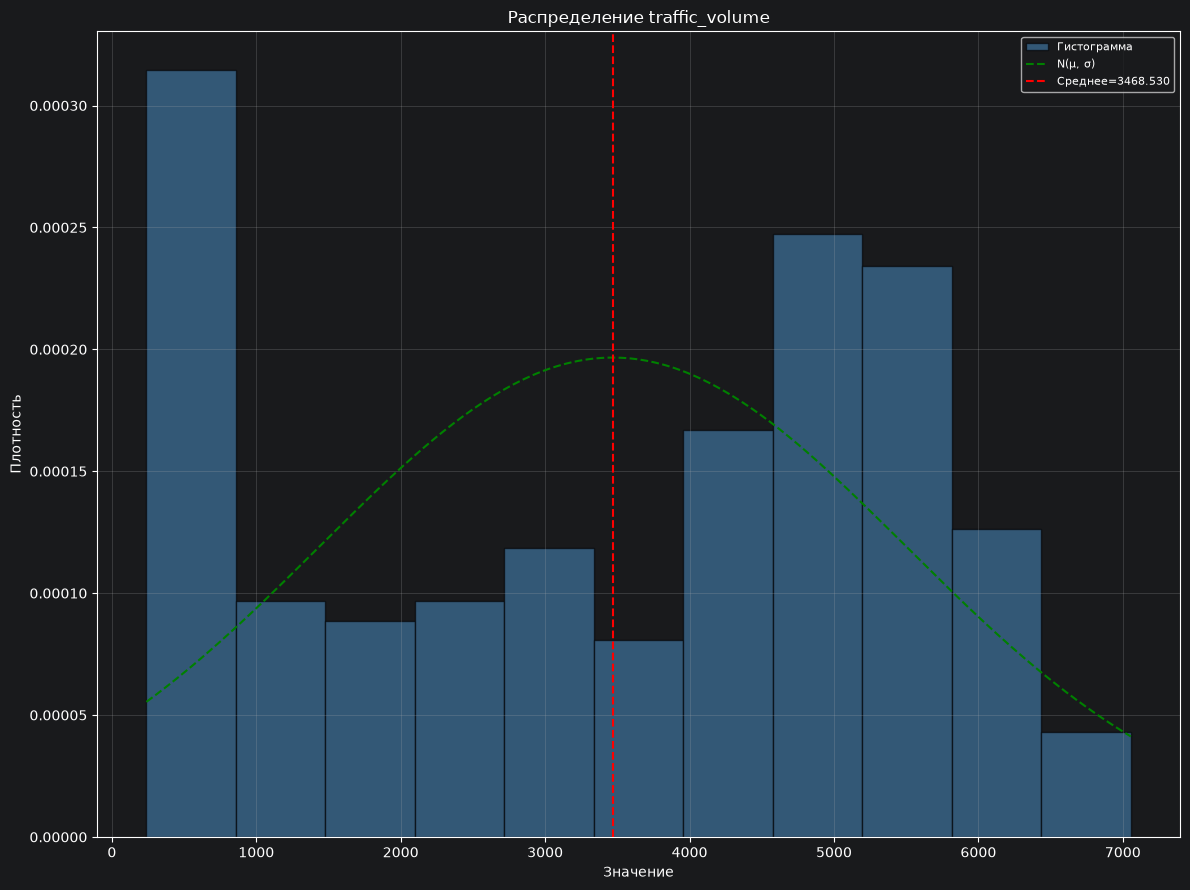


=== holiday ===
  Тип: категориальный
  Счет: 600
  Мода: nan
  Таблица частот:
     nan: 599
     Columbus Day: 1

=== temp ===
  Тип: числовой
  Среднее: 282.90555
  Стандартная ошибка: 0.20316215153849848
  Медиана: 282.35
  Мода: 282.6
  Стандартное отклонение: 4.976436063153137
  Дисперсия выборки: 24.764915890651093
  Эксцесс: 0.5782169142440896
  Асимметричность: 0.06695878441120422
  Интервал: 29.25999999999999
  Минимум: 268.91
  Максимум: 298.17
  Сумма: 169743.33
  Счет: 600

=== clouds_all ===
  Тип: числовой
  Среднее: 64.23833333333333
  Стандартная ошибка: 1.4581653866247513
  Медиана: 85.0
  Мода: 90.0
  Стандартное отклонение: 35.717611578187956
  Дисперсия выборки: 1275.747776850306
  Эксцесс: -0.9711317439189435
  Асимметричность: -0.8259761606986905
  Интервал: 100.0
  Минимум: 0.0
  Максимум: 100.0
  Сумма: 38543.0
  Счет: 600

=== weather_main ===
  Тип: категориальный
  Счет: 600
  Мода: Clouds
  Таблица частот:
     Clouds: 283
     Clear: 110
     Mist: 92
   

In [1]:
from ucimlrepo import fetch_ucirepo
from collections import Counter,defaultdict
import math
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

TARGET_DEFAULT = "traffic_volume"
def plot_distribution(values, title,bins="auto"):
    values = np.asarray(values, dtype=float)
    n = len(values)
    if n == 0:
        print(f"[{title}] Нет данных")
        return None

    mean = np.mean(values)
    std = np.std(values, ddof=1) if n > 1 else 0.0

    fig, ax = plt.subplots(1, 1, figsize=(12, 9))

    ax.hist(values, bins=bins, density=True, alpha=0.6,
            color="steelblue", edgecolor="black", label="Гистограмма")
    if n > 1 and std > 0:
        xs = np.linspace(values.min(), values.max(), 200)
        ax.plot(xs, stats.norm.pdf(xs, mean, std),
                color="green", ls="--", lw=1.5, label="N(μ, σ)")
    ax.axvline(mean,   color="red",    ls="--", lw=1.5, label=f"Среднее={mean:.3f}")
    ax.set_title(title)
    ax.set_xlabel("Значение")
    ax.set_ylabel("Плотность")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()
    return fig

def _numeric_stats(values,name):
    n = len(values)
    if n == 0:
        return {}
    plot_distribution(values, title= f"Распределение {name}")

    mean = sum(values) / n
    sorted_vals = sorted(values)
    if n % 2 == 0:
        median = (sorted_vals[n // 2 - 1] + sorted_vals[n // 2]) / 2
    else:
        median = sorted_vals[n // 2]

    counts = Counter(round(v, 6) for v in values)
    max_count = max(counts.values())
    modes = [v for v, c in counts.items() if c == max_count]
    mode = modes[0] if len(modes) == 1 else modes

    if n > 1:
        variance = sum((x - mean) ** 2 for x in values) / (n - 1)
        std_dev = math.sqrt(variance)
        std_error = std_dev / math.sqrt(n)
    else:
        variance = std_dev = std_error = 0.0

    if n > 2:
        m2 = sum((x - mean) ** 2 for x in values) / n
        m3 = sum((x - mean) ** 3 for x in values) / n
        m4 = sum((x - mean) ** 4 for x in values) / n
        skewness = m3 / (m2 ** 1.5) if m2 > 0 else 0.0
        kurtosis = m4 / (m2 ** 2) - 3 if m2 > 0 else 0.0
    else:
        skewness = kurtosis = 0.0

    return {
        "Тип": "числовой",
        "Среднее": mean,
        "Стандартная ошибка": std_error,
        "Медиана": median,
        "Мода": mode,
        "Стандартное отклонение": std_dev,
        "Дисперсия выборки": variance,
        "Эксцесс": kurtosis,
        "Асимметричность": skewness,
        "Интервал": max(values) - min(values),
        "Минимум": min(values),
        "Максимум": max(values),
        "Сумма": sum(values),
        "Счет": n,
    }


def _categorical_stats(values):
    n = len(values)
    if n == 0:
        return {"Тип": "категориальный", "Счет": 0, "Мода": None, "Таблица частот": {}}

    counts = Counter(values)
    freq_table = dict(sorted(counts.items(), key=lambda x: -x[1]))
    max_count = max(counts.values())
    modes = [v for v, c in counts.items() if c == max_count]
    mode = modes[0] if len(modes) == 1 else modes

    return {
        "Тип": "категориальный",
        "Счет": n,
        "Мода": mode,
        "Таблица частот": freq_table,
    }


def descriptive_analysis(data):
    if not data:
        return {}

    header = data[0]
    rows = data[1:]
    n_cols = len(header)

    columns = defaultdict(list)
    for row in rows:
        for i in range(min(n_cols, len(row))):
            columns[header[i]].append(row[i])

    result = {}

    for col_name, values in columns.items():
        numeric_values = []
        is_numeric = True
        for v in values:
            if v is None:
                continue
            s = str(v).strip().replace(" ", "").replace("\u00a0", "")
            if s == "":
                continue
            try:
                numeric_values.append(float(s.replace(",", ".")))
            except ValueError:
                is_numeric = False
                break

        if is_numeric and numeric_values:
            result[col_name] = _numeric_stats(numeric_values,col_name)

        else:
            clean_values = [
                str(v).strip() for v in values
                if v is not None and str(v).strip() != ""
            ]
            result[col_name] = _categorical_stats(clean_values)

    return result

if __name__ == "__main__":
    TARGET = TARGET_DEFAULT
    dataset = fetch_ucirepo(id=492)
    df_raw = dataset.data.features.copy()
    df_raw[TARGET] = dataset.data.targets[TARGET]
    cols_to_drop = ["weather_description", "rain_1h", "snow_1h"]
    df_raw = df_raw.drop(columns=cols_to_drop, errors="ignore")
    df_raw = df_raw.head(600).reset_index(drop=True)

    raw = [df_raw.columns.tolist()] + df_raw.astype(str).values.tolist()

    # Описательная статистика
    stats_result = descriptive_analysis(raw)
    for col, s in stats_result.items():
        print(f"\n=== {col} ===")
        for k, v in s.items():
            if k == "Таблица частот":
                print(f"  {k}:")
                for val, cnt in list(v.items())[:10]:
                    print(f"     {val}: {cnt}")
            else:
                print(f"  {k}: {v}")



Для анализа был выбран датасет Metro Interstate Traffic Volume (600 значений).

Датасет содержит 6 переменных:

holiday - название праздника, категориальная независимая переменная

temp - температура в Кельвинах, числовая непрерывная независимая переменная

clouds_all - облачность, числовая дискретная независимая переменная

weather_main - описание погоды,категориальная независимая переменная

date_time - время, категориальная независимая переменная

traffic_volume - значение трафика метро, числовая непрерывная зависимая переменная

После первичного анализа можно сделать выводы:

**Переменная temp**

Значения эксцесса (0.57) и асимметричности (0.06) указывают на минимальное отклонение от нормального распределения; среднее, медиана и мода почти равны; график близок к графику нормального распределения. Распределение переменной temp можно назвать нормальным.

**Переменная clouds_all**

Значения эксцесса (−1.60) и асимметричности (−0.34) говорят о некритичном отклонении от нормального распределения. Асимметрия слабая, а отрицательный эксцесс указывает на плосковершинность. На графике видны выбросы.

**Зависимая переменная traffic_volume**

Значения эксцесса (−1.30) и асимметричности (−0.24) показывают некритичное отклонение от нормального распределения по форме. На графике видны выбросы. Дескриптивный анализ показывает существенное различие между медианой и средним, что объясняется влиянием этих выбросов.
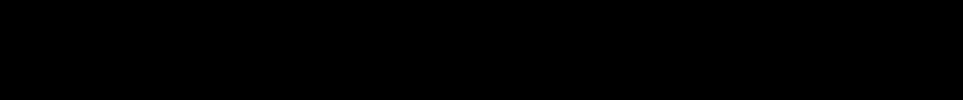
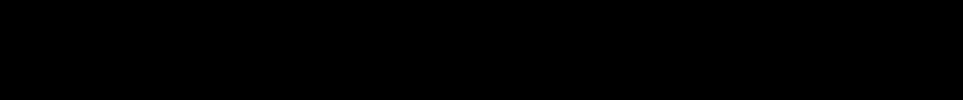
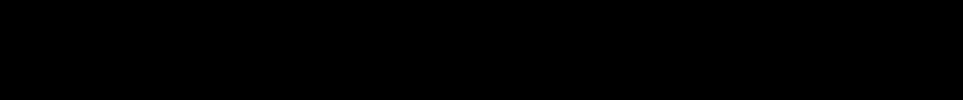
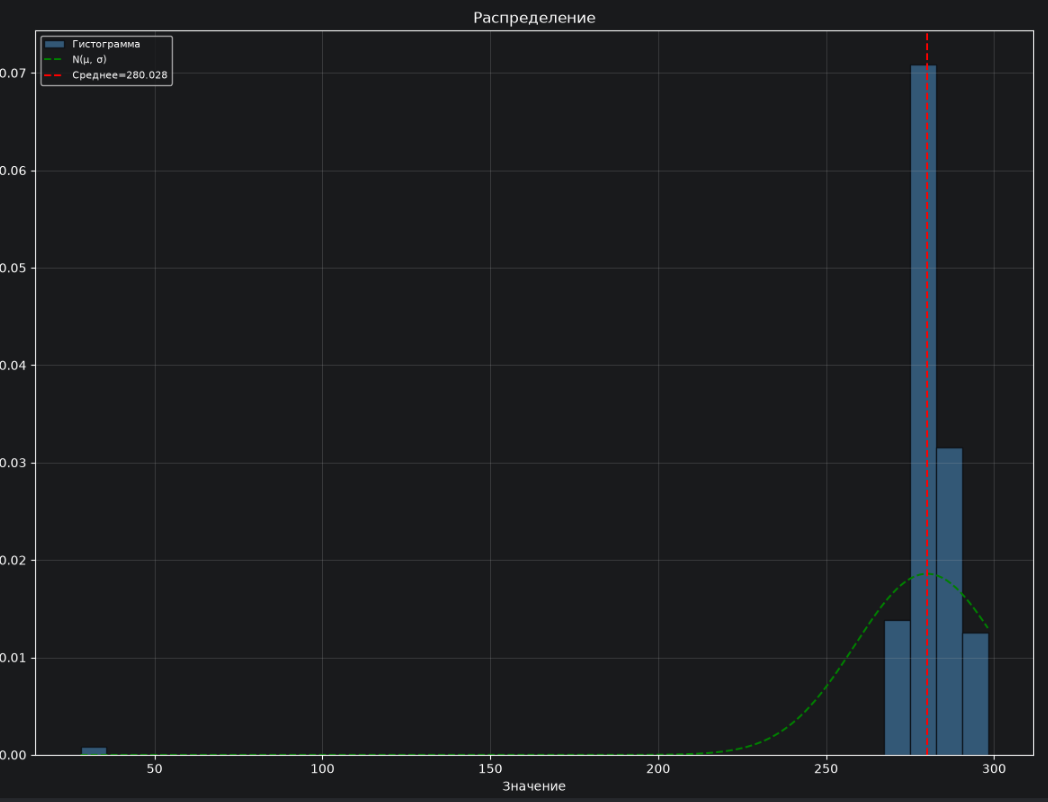
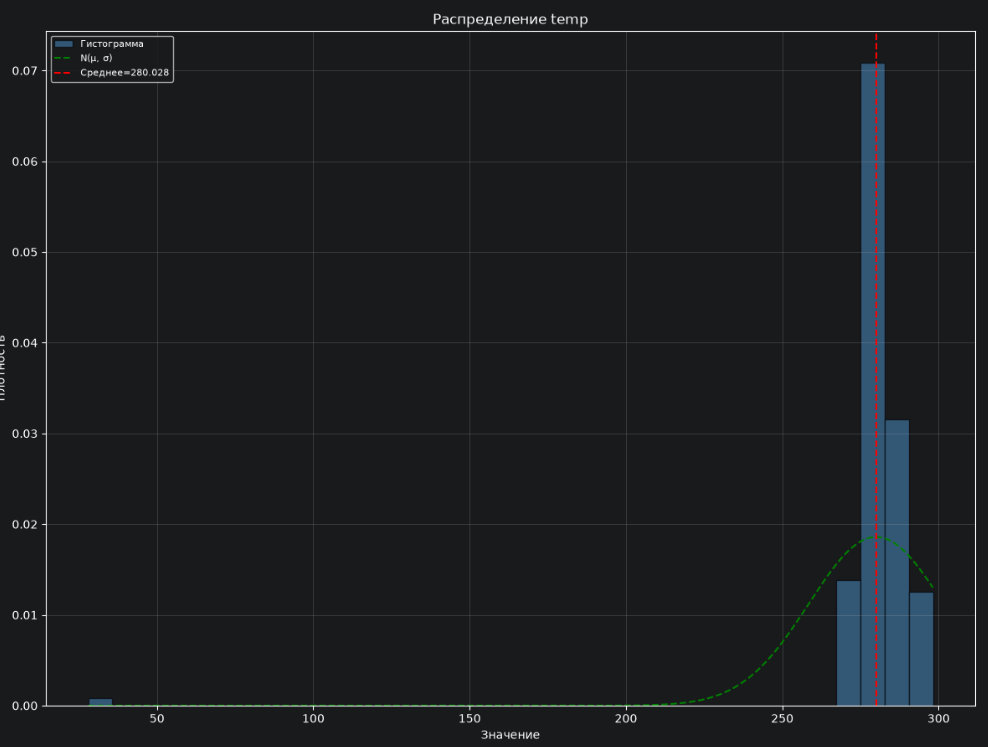
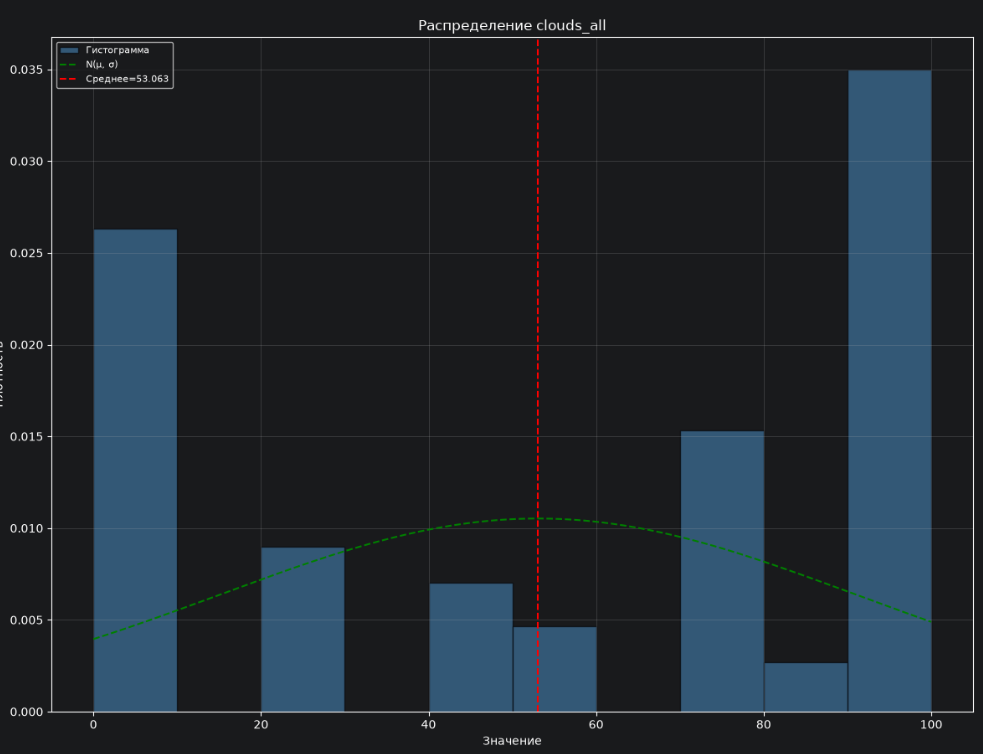
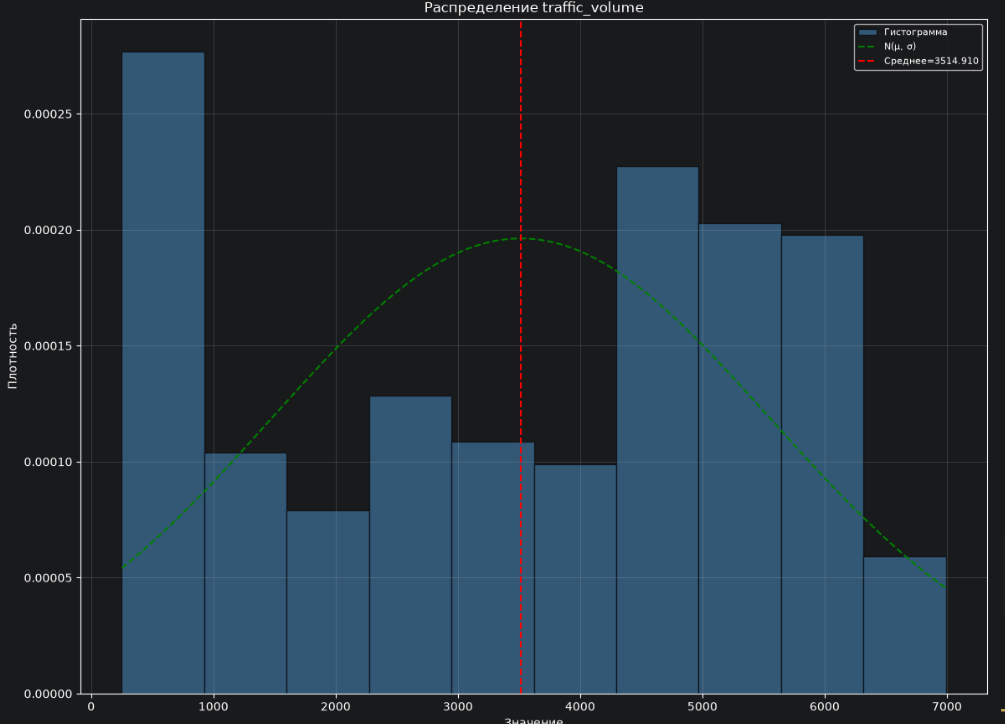

In [2]:
import pandas as pd

def add_time_features(df, date_col,
                      unit=None, date_format=None,
                      drop_original=True, inplace=False):

    if not inplace:
        df = df.copy()

    if date_col not in df.columns:
        raise ValueError(f"Столбец '{date_col}' не найден. "
                         f"Доступные: {list(df.columns)}")

    if unit is not None:
        dt = pd.to_datetime(df[date_col], unit=unit, errors="coerce")
    elif date_format is not None:
        dt = pd.to_datetime(df[date_col], format=date_format, errors="coerce")
    else:
        dt = pd.to_datetime(df[date_col], errors="coerce")

    n_bad = dt.isna().sum()
    if n_bad > 0:
        print(f"[add_time_features] Не удалось распарсить {n_bad} значений "
              f"({n_bad / len(dt) * 100:.2f}%).")

    # числовые компоненты
    df["year"]  = dt.dt.year
    df["month"] = dt.dt.month
    df["day"]   = dt.dt.day

    # часть суток
    hour = dt.dt.hour

    def _part(h):
        if pd.isna(h):
            return "unknown"
        if 6 <= h < 12:
            return "morning"
        if 12 <= h < 18:
            return "day"
        if 18 <= h < 24:
            return "evening"
        return "night"

    df["part_of_day"] = hour.map(_part)


    if drop_original:
        df = df.drop(columns=[date_col])

    if inplace:
        return None
    return df


header = [str(h).strip() for h in raw[0]]
rows = raw[1:]
df = pd.DataFrame(rows, columns=header)

for col in df.columns:
    converted = pd.to_numeric(df[col], errors="coerce")
    if converted.notna().mean() > 0.9:
        df[col] = converted

if "date_time" in df.columns:
    df = add_time_features(df, "date_time", unit=None, drop_original=True)


cat_cols = [
    c for c in df.columns
    if c != TARGET_DEFAULT
       and not pd.api.types.is_numeric_dtype(df[c])
       and df[c].notna().any()
]
original_cats = list(cat_cols)

if cat_cols:
    dummies = pd.get_dummies(
        df[cat_cols].astype(str),
        prefix=cat_cols,
        drop_first=True,
        dtype=int
    )
    df = df.drop(columns=original_cats)
    df = pd.concat([df, dummies], axis=1)

df = df.apply(pd.to_numeric, errors="coerce")

Для дальнейшего анализа было проведено преобразование категориальных переменных:
 1) Переменная holiday удалена (первичный анализ показал сильный перевес в сторону одного значения)

 2) Переменная weather_main была закодирована с помощью метода One Hot Encoding:
    weather_main_Clouds

    weather_main_Drizzle

    weather_main_Fog

    weather_main_Haze

    weather_main_Mist

    weather_main_Rain

    weather_main_Thunderstorm

3) Переменная datetime была закодирована в 4 переменных:

   День был выделен в переменную - day

   Время было разделено на 3 переменных

   part_of_day_evening

   part_of_day_morning

   part_of_day_night


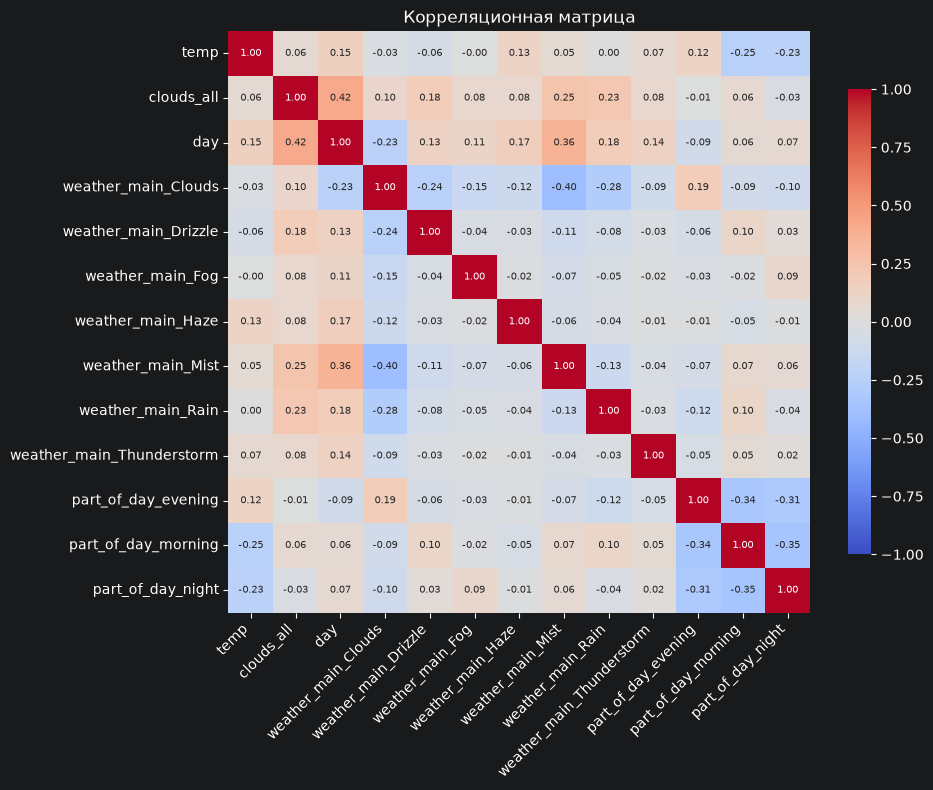


 VIF 
weather_main_Clouds          3.507414
weather_main_Mist            3.378415
weather_main_Rain            2.444358
clouds_all                   2.374169
weather_main_Drizzle         2.086109
part_of_day_morning          1.891995
part_of_day_night            1.825135
day                          1.626256
part_of_day_evening          1.542721
weather_main_Fog             1.401547
weather_main_Haze            1.354029
temp                         1.332536
weather_main_Thunderstorm    1.249019
dtype: float64


In [3]:
import seaborn as sns
from sklearn.linear_model import LinearRegression
def compute_vif(df):
    vif_data = {}
    feature_names = df.columns.tolist()

    for col in feature_names:
        X_others = df.drop(columns=[col]).values
        y = df[col].values

        model = LinearRegression().fit(X_others, y)
        r_squared = model.score(X_others, y)

        if r_squared >= 1.0:
            vif = float("inf")
        else:
            vif = 1.0 / (1.0 - r_squared)

        vif_data[col] = vif

    return pd.Series(vif_data).sort_values(ascending=False)

feature_cols = [c for c in df.columns if c != TARGET]
df_num = df[feature_cols].dropna(axis=1, how="all")
df_num = df_num.loc[:, df_num.std() > 0]


if df_num.shape[1] >= 2:
    corr_matrix = df_num.corr()

    plt.figure(figsize=(max(10, 0.6 * len(corr_matrix)),
                        max(8, 0.6 * len(corr_matrix))))
    sns.heatmap(corr_matrix, annot=True, cmap="coolwarm",
                fmt=".2f", vmin=-1, vmax=1, square=True,
                cbar_kws={"shrink": 0.8},
                annot_kws={"size": 7})
    plt.title("Корреляционная матрица")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    # VIF
vif_num = compute_vif(df_num)
print("\n VIF ")
print(vif_num)

Анализ корреляционной матрицы и коэффициентов VIF показал, что имеет место мультиколлинеарность (значения VIF weather_main_Clouds и weather_main_Mist   > 3)

Train: (480, 13), Test: (120, 13)

--- Linear ---
  RMSE: 1148.3422
  R²: 0.6773
  MAPE (%): 51.3610
  CV RMSE (mean): 1073.6354
  CV RMSE (std): 64.9667

--- Lasso ---
  RMSE: 1148.3015
  R²: 0.6774
  MAPE (%): 51.3599
  CV RMSE (mean): 1073.6272
  CV RMSE (std): 64.9679

--- Ridge ---
  RMSE: 1147.1323
  R²: 0.6780
  MAPE (%): 51.5458
  CV RMSE (mean): 1073.4750
  CV RMSE (std): 65.0546

 ИТОГИ 
             RMSE      R²  MAPE (%)  CV RMSE (mean)  CV RMSE (std)
Linear  1148.3422  0.6773   51.3610       1073.6354        64.9667
Lasso   1148.3015  0.6774   51.3599       1073.6272        64.9679
Ridge   1147.1323  0.6780   51.5458       1073.4750        65.0546


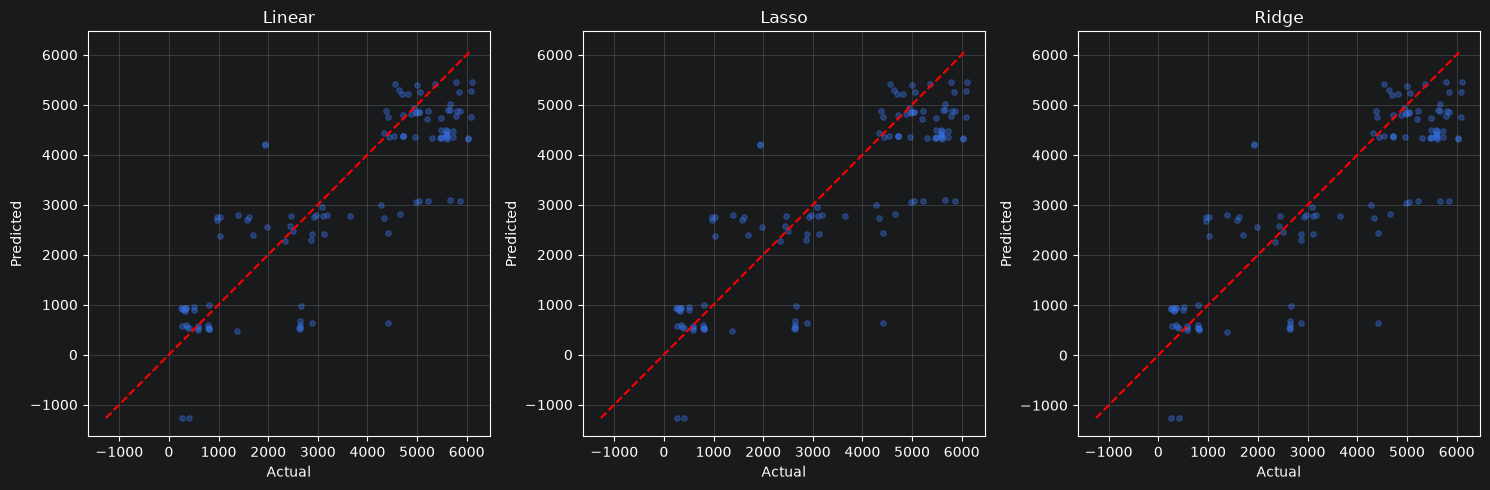

In [4]:
from sklearn.linear_model import  Lasso, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    train_test_split, KFold, cross_val_score, GridSearchCV
)
from sklearn.metrics import (
    mean_squared_error, r2_score, mean_absolute_percentage_error
)
def build_linear_model():
    return Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ])


def build_lasso_model(alpha=0.01, max_iter=50000, tol=1e-3, random_state=42):
    return Pipeline([
        ("scaler", StandardScaler()),
        ("model", Lasso(alpha=alpha, max_iter=max_iter,
                        tol=tol, random_state=random_state))
    ])


def build_ridge_model(alpha=1.0, random_state=42):
    return Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=alpha, random_state=random_state))
    ])


def build_all_regression_models(alpha_lasso=0.01, alpha_ridge=1.0):
    return {
        "Linear": build_linear_model(),
        "Lasso":  build_lasso_model(alpha=alpha_lasso),
        "Ridge":  build_ridge_model(alpha=alpha_ridge),
    }


def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    mask = y_true != 0
    if mask.sum() > 0:
        mape = mean_absolute_percentage_error(y_true[mask], y_pred[mask]) * 100
    else:
        mape = float("nan")

    return {"RMSE": rmse, "R²": r2, "MAPE (%)": mape}


def fit_and_evaluate(model, X_train, y_train, X_test, y_test,
                     cv_folds=5, random_state=42, name="model"):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    metrics = regression_metrics(y_test, y_pred)

    kf = KFold(n_splits=cv_folds, shuffle=True, random_state=random_state)
    cv_scores = cross_val_score(
        model, X_train, y_train,
        cv=kf, scoring="neg_root_mean_squared_error"
    )
    metrics["CV RMSE (mean)"] = -cv_scores.mean()
    metrics["CV RMSE (std)"]  = cv_scores.std()

    print(f"\n--- {name} ---")
    for k, v in metrics.items():
        print(f"  {k}: {v:.4f}")

    return metrics, y_pred


def train_all_models(X, y, test_size=0.2, cv_folds=5,
                     alpha_lasso=0.01, alpha_ridge=1.0,
                     shuffle=False, random_state=42):

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, shuffle=shuffle,
        random_state=random_state
    )
    print(f"Train: {X_train.shape}, Test: {X_test.shape}")

    models = build_all_regression_models(
        alpha_lasso=alpha_lasso, alpha_ridge=alpha_ridge
    )

    results, trained, preds = {}, {}, {}

    for name, model in models.items():
        metrics, y_pred = fit_and_evaluate(
            model, X_train, y_train, X_test, y_test,
            cv_folds=cv_folds, random_state=random_state, name=name
        )
        results[name] = metrics
        trained[name] = model
        preds[name] = y_pred

    return results, trained, preds, (X_train, X_test, y_train, y_test)


def tune_alpha(model_builder, X_train, y_train,
               alphas=None, cv_folds=5):
    if alphas is None:
        alphas = np.logspace(-3, 3, 30)

    grid = GridSearchCV(
        estimator=model_builder(),
        param_grid={"model__alpha": alphas},
        cv=cv_folds,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    )
    grid.fit(X_train, y_train)
    print(f"Best alpha: {grid.best_params_['model__alpha']:.6f}  "
          f"CV RMSE: {-grid.best_score_:.4f}")
    return grid.best_estimator_


def plot_predicted_vs_actual(y_true, preds_dict):
    n = len(preds_dict)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 5))
    if n == 1:
        axes = [axes]

    y_true = np.asarray(y_true, dtype=float)

    for ax, (name, y_pred) in zip(axes, preds_dict.items()):
        y_pred = np.asarray(y_pred, dtype=float)
        ax.scatter(y_true, y_pred, alpha=0.4, s=15)
        lims = [min(y_true.min(), y_pred.min()),
                max(y_true.max(), y_pred.max())]
        ax.plot(lims, lims, "r--", lw=1.5)
        ax.set_xlabel("Actual")
        ax.set_ylabel("Predicted")
        ax.set_title(name)
        ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()
X = df_num
y = pd.to_numeric(df[TARGET], errors="coerce")

mask = y.notna() & X.notna().all(axis=1)
X = X[mask]
y = y[mask]

results, models, preds, (X_train, X_test, y_train, y_test) = train_all_models(
    X, y, test_size=0.2, cv_folds=5,
    alpha_lasso=0.01, alpha_ridge=1.0,
    shuffle=False
)

print("\n ИТОГИ ")
print(pd.DataFrame(results).T.round(4))

plot_predicted_vs_actual(y_test, preds)

Были построены три регрессионные модели. Коэффициент детерминации каждой модели близок к 0.67 — модель объясняет около 67% вариации зависимой переменной. Модели имеют умеренную объяснительную способность. MAPE = 51.4% для всех моделей: в среднем модель ошибается на 51% от фактического значения трафика, , что говорит о низкой точности. RMSE ≈ 1148 — абсолютная ошибка модели сопоставима с половиной стандартного отклонения целевой переменной, что соответствует умеренной точности прогноза.

Компонент для 95% дисперсии: 11


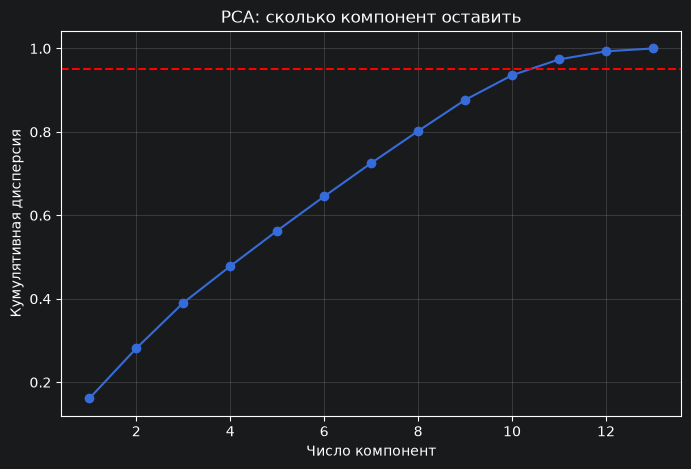


--- Linear+PCA [PCA] ---
  RMSE: 1139.4182
  R²: 0.6823
  MAPE (%): 52.1580
  CV RMSE (mean): 1075.1766
  CV RMSE (std): 64.4532

--- Lasso+PCA [PCA] ---
  RMSE: 1139.3870
  R²: 0.6824
  MAPE (%): 52.1568
  CV RMSE (mean): 1075.1755
  CV RMSE (std): 64.4557

--- Ridge+PCA [PCA] ---
  RMSE: 1138.4904
  R²: 0.6829
  MAPE (%): 52.3513
  CV RMSE (mean): 1074.9937
  CV RMSE (std): 64.5440

ИТОГИ (PCA, 11 компонент):
                       RMSE      R²  MAPE (%)  CV RMSE (mean)  CV RMSE (std)
Linear+PCA [PCA]  1139.4182  0.6823   52.1580       1075.1766        64.4532
Lasso+PCA [PCA]   1139.3870  0.6824   52.1568       1075.1755        64.4557
Ridge+PCA [PCA]   1138.4904  0.6829   52.3513       1074.9937        64.5440


In [5]:
from sklearn.pipeline import make_pipeline
from sklearn.decomposition import PCA

def _pca_preprocessor(n_components):
    return [
        ("scaler", StandardScaler()),
        ("pca",    PCA(n_components=n_components)),
    ]


def build_linear_model_pca(n_components=11):
    return Pipeline(_pca_preprocessor(n_components) + [
        ("model", LinearRegression())
    ])


def build_lasso_model_pca(n_components=11, alpha=0.01,
                          max_iter=50000, tol=1e-3, random_state=42):
    return Pipeline(_pca_preprocessor(n_components) + [
        ("model", Lasso(alpha=alpha, max_iter=max_iter,
                        tol=tol, random_state=random_state))
    ])


def build_ridge_model_pca(n_components=11, alpha=1.0, random_state=42):
    return Pipeline(_pca_preprocessor(n_components) + [
        ("model", Ridge(alpha=alpha, random_state=random_state))
    ])
def build_all_regression_models_pca(n_components=11,
                                    alpha_lasso=0.01, alpha_ridge=1.0):
    return {
        "Linear+PCA": build_linear_model_pca(n_components),
        "Lasso+PCA":  build_lasso_model_pca(n_components, alpha=alpha_lasso),
        "Ridge+PCA":  build_ridge_model_pca(n_components, alpha=alpha_ridge),
    }

pca_pipe = make_pipeline(StandardScaler(), PCA())
X_proj = pca_pipe.fit_transform(X)

pca = pca_pipe.named_steps["pca"]

n95 = np.searchsorted(np.cumsum(pca.explained_variance_ratio_), 0.95) + 1
print(f"Компонент для 95% дисперсии: {n95}")

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(pca.explained_variance_ratio_)+1),
         np.cumsum(pca.explained_variance_ratio_), "o-")
plt.axhline(0.95, color="red", ls="--")
plt.xlabel("Число компонент"); plt.ylabel("Кумулятивная дисперсия")
plt.title("PCA: сколько компонент оставить"); plt.grid(alpha=0.3); plt.show()
models_PCA = build_all_regression_models_pca(n_components=11)

all_results = {}

for name, model in models_PCA.items():
    metrics, _ = fit_and_evaluate(
        model, X_train, y_train, X_test, y_test,
        cv_folds=5, random_state=42, name=f"{name} [PCA]"
    )
    all_results[f"{name} [PCA]"] = metrics

print("\nИТОГИ (PCA, 11 компонент):")
print(pd.DataFrame(all_results).T.round(4))

Для устранения мультиколлинеарности был применен метод главных компонент (PCA). Были найден 11 главных компонент максимальной дисперсии данных.

Были построены регрессионные модели с использованием в качестве признаков не исходных данных, а главных компонент.

Применение PCA не дало значимого улучшения качества моделей. Прирост R² составил всего 0.005, RMSE снизилась незначительно, MAPE выросла.